# Figure 5 · One lever geometry for all modes, and blind prediction from sparse data

Production notebook for main-text Fig. 5. Numbers from notebook 05b (Phase 2g, soft probe,
cached in `results/_cache_05b.json`) and notebook 05a (stiff probe B, blind node prediction).

- **Frame.** The clamp position in stage coordinates comes from the static-shape InvOLS ruler,
  1/InvOLS ∝ u²(3A − u), u = x − c, fitted to the dense map's per-position force curves.
- **Joint EB.** One Euler–Bernoulli geometry shared by CR1–CR5 (contact and cone stiffness,
  setback, tip height, clamp, length), per-mode damping, electrostatic weight, complex gain and a
  small frequency offset. Stage 1 fits frequencies + nodes; the ladder adds the complex spectra.
- **Leave one mode out.** Stage 1 and the ladder are refitted without the held-out mode (no
  leakage), then that mode is predicted.
- **Small N.** Joint fits on N equispaced positions against single-band arms (notebook 05b).
- **Stiff probe.** Nodes predicted by the blind EB fit (frequencies, Q, static shape only),
  in the lever frame, against the dense-map nodes (run R2; R1 in the SI).

In [1]:
%matplotlib inline
import sys, pathlib
# make the paper package importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fmmpaper as F
from fmmpaper import io, axis, spectra, domains, recon, plotting as fp, results
fp.setup()
print(F.config.describe())

project : /home/claude/work/paper_analysis
data_root: /mnt/user-data/uploads/ActiveModeMap  (ok)
amm_repo : /home/claude/work  (ok)
eb_repo  : C:\Users\lz1\Documents\Github\EB-Solver-CResonance  (MISSING)
fmm_code_zip: /mnt/user-data/uploads/ActiveModeMap_repo/Manuscript_FMM/FMM_analysis_code.zip  (ok)


In [2]:
import json, re
from fmmpaper import io as _io
C = json.loads((F.config.RESULTS_DIR / "_cache_05b.json").read_text())
J = pd.read_csv(F.config.RESULTS_DIR / "fig5b_joint_geometry.csv")
NP = pd.read_csv(F.config.RESULTS_DIR / "fig5_contact_state.csv")
BANDS = ["CR1", "CR2", "CR3", "CR4", "CR5"]
p = _io.path_of("ppp_dense_1um"); log = p.with_name(p.name.replace("_checkpoint.npz", "_log.txt")).read_text(errors="replace")
xs, inv = [], []
for blk in re.split(r"=== position \d+: x = ", log)[1:]:
    m = re.search(r"InvOLS ([\d.e+-]+) m/V", blk)
    if m:
        xs.append(float(blk.split()[0])); inv.append(float(m.group(1)))
xs, inv = np.array(xs), np.array(inv)
r = C["ruler_all"]; c, A = r["c_um"], r["A_um"]
u = np.clip(xs - c, 1e-3, None); shape = np.where(u <= A, u**2 * (3*A - u), 2*A**3 + (u - A) * 3*A**2)
g = np.exp(np.mean(np.log((1/inv) / shape)))
s1 = C["stage1"]["free_frame"]
nodes = []
for b in BANDS:
    for t in C["truth"][b]["nodes"]:
        mdl = min(s1["model_nodes"][b], key=lambda m: abs(m - t))
        nodes.append(dict(mode=b, measured=t, model=mdl, diff=mdl - t))
nodes = pd.DataFrame(nodes)
lomo = pd.DataFrame([dict(mode=b, heldout=C["lomo"][b]["score"]["nrmse"], node=C["lomo"][b]["score"]["node_err_um"],
                          freq_err_pct=C["lomo"][b]["eig_freq_err_pct"]) for b in BANDS])
lomo["all_modes"] = [s["nrmse"] for s in C["ladder"]["M1f"]["score"]]
lomo["single_band"] = [C["ind"][b]["nrmse"] for b in BANDS]
print(f"ruler clamp {c:.1f} um, EB clamp {s1['P']['c_um']:.1f} um, L {s1['P']['L_um']:.1f} um; "
      f"stage-1 frequency errors {np.round(s1['freq_err_pct'], 2)} %")
lomo.round(3)

ruler clamp -19.0 um, EB clamp -18.3 um, L 463.3 um; stage-1 frequency errors [-1.46  1.14  1.66  1.86  1.18] %


,mode,heldout,node,freq_err_pct,all_modes,single_band
0,CR1,0.134,1.000,-2.826,0.134,0.152
1,CR2,0.142,1.000,1.338,0.141,0.146
2,CR3,0.230,1.000,2.036,0.232,0.243
3,CR4,0.342,1.667,1.916,0.343,0.496
4,CR5,0.477,1.833,1.317,0.473,0.462


## The figure

[PosixPath('/home/claude/work/paper_analysis/figures/Fig5_one_geometry.png'),
 PosixPath('/home/claude/work/paper_analysis/figures/Fig5_one_geometry.pdf')]

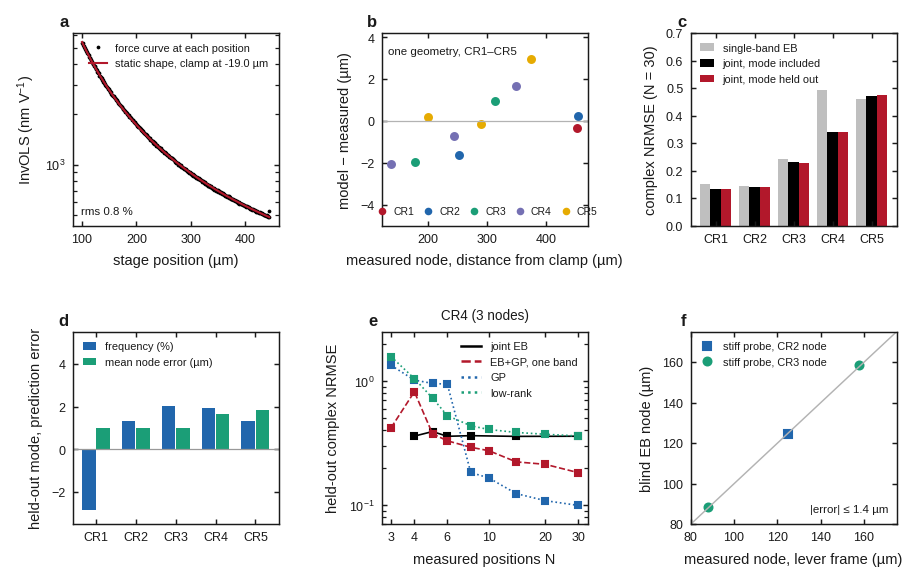

In [3]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(fp.WIDTH_IN["double"], fp.WIDTH_IN["double"] * 0.6))
gs = GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.5)
ax = [fig.add_subplot(gs[i // 3, i % 3]) for i in range(6)]
MC = {b: fp.C[b.lower()] for b in BANDS}

# a  InvOLS ruler
a = ax[0]
a.semilogy(xs, inv * 1e9, ".", color="k", ms=1.6, label="force curve at each position")
a.semilogy(xs, 1e9 / (g * shape), color=fp.C["ebgp"], lw=1, label=f"static shape, clamp at {c:.1f} µm")
a.set_xlabel("stage position (µm)"); a.set_ylabel("InvOLS (nm V$^{-1}$)")
a.legend(loc="upper right", fontsize=5.3, handlelength=1.6)
a.text(0.04, 0.06, f"rms {100 * r['rms']:.1f} %", transform=a.transAxes, fontsize=5.5)
fp.panel_label(a, "a")

# b  joint-fit nodes vs measured
b_ = ax[1]
for bnd in BANDS:
    d = nodes[nodes["mode"] == bnd]
    b_.plot(d.measured - c, d["diff"], "o", color=MC[bnd], ms=3.3, label=bnd)
b_.axhline(0, color="0.7", lw=0.6)
b_.set_ylim(-5, 4.2); b_.set_xlabel("measured node, distance from clamp (µm)"); b_.set_ylabel("model − measured (µm)")
b_.legend(loc="lower center", fontsize=5, ncol=5, handletextpad=0.05, columnspacing=0.35, markerscale=0.8)
b_.text(0.03, 0.93, "one geometry, CR1–CR5", transform=b_.transAxes, fontsize=5.5, va="top")
fp.panel_label(b_, "b")

# c  leave-one-mode-out
cc = ax[2]; nn = np.arange(5)
cc.bar(nn - 0.27, lomo.single_band, width=0.26, color="0.75", label="single-band EB")
cc.bar(nn, lomo.all_modes, width=0.26, color=fp.C["meas"], label="joint, mode included")
cc.bar(nn + 0.27, lomo.heldout, width=0.26, color=fp.C["ebgp"], label="joint, mode held out")
cc.set_xticks(nn); cc.set_xticklabels(BANDS); cc.set_ylabel("complex NRMSE (N = 30)"); cc.set_ylim(0, 0.7)
cc.legend(loc="upper left", fontsize=5.3, handlelength=1.2)
fp.panel_label(cc, "c")

# d  held-out predictions: frequency and nodes
dd = ax[3]
dd.bar(nn - 0.18, lomo.freq_err_pct, width=0.34, color=fp.C["gp"], label="frequency (%)")
dd.bar(nn + 0.18, lomo.node, width=0.34, color=fp.C["lowrank"], label="mean node error (µm)")
dd.axhline(0, color="0.6", lw=0.6)
dd.set_xticks(nn); dd.set_xticklabels(BANDS); dd.set_ylabel("held-out mode, prediction error"); dd.set_ylim(-3.5, 5.5)
dd.legend(loc="upper left", fontsize=5.3, handlelength=1.2)
fp.panel_label(dd, "d")

# e  small N: joint EB vs single-band arms, CR3 and CR4
e = ax[4]
for bnd, mk in (("CR4", "s"),):
    for arm, col, ls in (("joint EB", fp.C["meas"], "-"), ("single-band EB+GP", fp.C["ebgp"], "--"),
                         ("single-band GP", fp.C["gp"], ":"), ("single-band low-rank", fp.C["lowrank"], ":")):
        d = J[(J["mode"] == bnd) & (J.arm == arm)].sort_values("N")
        e.plot(d.N, d.nrmse, ls, color=col, marker=mk, ms=2.5, lw=0.8, mfc="w" if bnd == "CR3" else col)
fp.n_axis(e, ticks=(3, 4, 6, 10, 20, 30)); e.set_yscale("log"); e.set_ylim(0.07, 2.5)
e.set_xlabel("measured positions N"); e.set_ylabel("held-out complex NRMSE")
from matplotlib.lines import Line2D
e.legend(handles=[Line2D([], [], color=fp.C["meas"], label="joint EB"), Line2D([], [], color=fp.C["ebgp"], ls="--", label="EB+GP, one band"),
                  Line2D([], [], color=fp.C["gp"], ls=":", label="GP"), Line2D([], [], color=fp.C["lowrank"], ls=":", label="low-rank"),
],
         loc="upper right", fontsize=5.3, handlelength=1.8)
e.set_title("CR4 (3 nodes)", fontsize=6.5)
fp.panel_label(e, "e")

# f  stiff probe B: blind EB node prediction
f_ = ax[5]
NP = NP[NP.run == "R2"]
for mode, mk in (("CR2", "s"), ("CR3", "o")):
    d = NP[NP["mode"] == mode]
    f_.plot(d.measured_lever_um, d.blind_EB_um, mk, color=fp.C[mode.lower()], ms=3.8, label=f"stiff probe, {mode} node")
lim = [80, 175]; f_.plot(lim, lim, color="0.7", lw=0.7)
f_.set_xlim(lim); f_.set_ylim(lim)
f_.set_xlabel("measured node, lever frame (µm)"); f_.set_ylabel("blind EB node (µm)")
f_.legend(loc="upper left", fontsize=5.3, handlelength=1.2)
f_.text(0.96, 0.06, f"|error| ≤ {NP.diff_um.abs().max():.1f} µm", transform=f_.transAxes, ha="right", fontsize=5.5)
fp.panel_label(f_, "f")
fp.save(fig, "Fig5_one_geometry")

In [4]:
results.save("fig5_main", dict(ruler=r, stage1=dict(P=s1["P"], freq_err_pct=s1["freq_err_pct"]), nodes=nodes.to_dict("records"),
                               lomo=lomo.to_dict("records"), stiffB_nodes=NP.to_dict("records")), table=lomo)

PosixPath('/home/claude/work/paper_analysis/results/fig5_main.json')